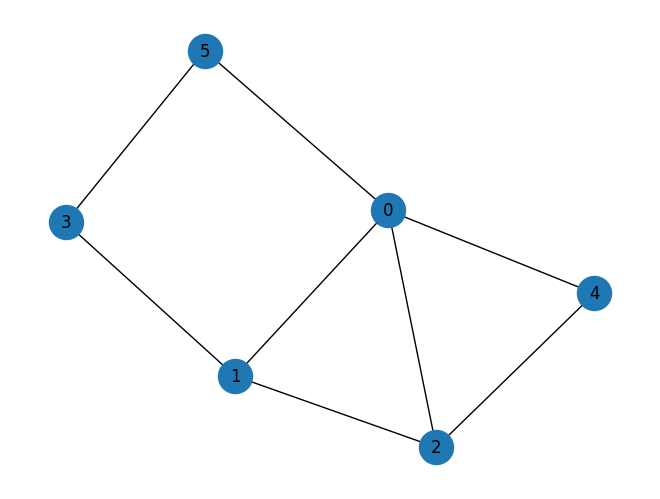

In [1]:
import matplotlib.pyplot as plt
import rustworkx as rx
from rustworkx.visualization import mpl_draw as draw_graph
import numpy as np

n = 6

graph = rx.PyGraph()
graph.add_nodes_from(np.arange(0, n, 1))
edge_list = [(0, 1, 1), 
             (0, 2, 1), 
             (0, 4, 1), 
             (0, 5, 1), 
             (1, 2, 1), 
             (1, 3, 1), 
             (2, 4, 1), 
             (3, 5, 1)]
graph.add_edges_from(edge_list)
draw_graph(graph, node_size=600, with_labels=True)


# Hamiltonian

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from functools import reduce

# krons 함수 정의
def krons(*arr):
    return reduce(np.kron, arr)

# Z와 I 행렬 정의
z = np.array([
    [1, 0],
    [0, -1]
])
i = np.identity(2)

def ham(g):
    edges = [g.get_edge_endpoints_by_index(i) for i in range(len(edge_list))]
    num_nodes = len(g.node_indices())
    
    def z_term(m, n):
        terms = [i] * num_nodes
        terms[m] = z
        terms[n] = z
        return krons(*terms)
    
    hamiltonian = sum(z_term(m, n) for m, n in edges)
    return 0.5 * (len(edges) * krons(*[i]*num_nodes) - hamiltonian)


# Hamiltonian 계산 및 출력
H = ham(graph)
print("Max-Cut Hamiltonian:")
print(np.diag(H))
hamiltonian = H


Max-Cut Hamiltonian:
[0. 2. 2. 4. 2. 2. 4. 4. 3. 5. 3. 5. 5. 5. 5. 5. 3. 5. 5. 7. 3. 3. 5. 5.
 4. 6. 4. 6. 4. 4. 4. 4. 4. 4. 4. 4. 6. 4. 6. 4. 5. 5. 3. 3. 7. 5. 5. 3.
 5. 5. 5. 5. 5. 3. 5. 3. 4. 4. 2. 2. 4. 2. 2. 0.]


(-0.2, 8.4)

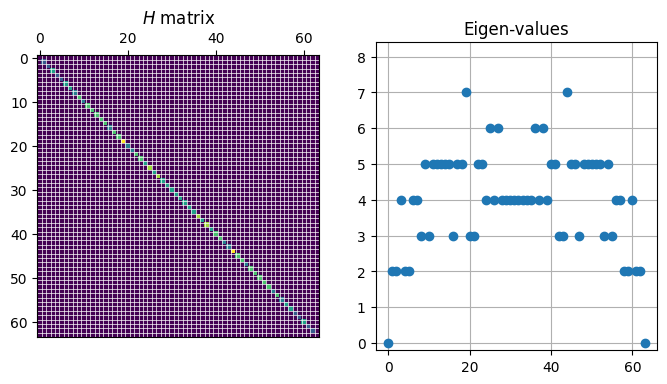

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(H)
axes[0].set_title("$H$ matrix")
axes[0].xaxis.set_ticks_position('top')
axes[0].xaxis.set_label_position('top')
line_data = np.arange(int(2**n)+1)-0.5
for x in line_data:
    axes[0].axvline(x=x, color='white', linestyle='-', linewidth=0.5)
# Add horizontal grid lines
for y in line_data:
    axes[0].axhline(y=y, color='white', linestyle='-', linewidth=0.5)

axes[1].plot(np.diag(H), "o")
axes[1].grid()
axes[1].set_title("Eigen-values")
axes[1].set_ylim(-0.2, 1.2*max(np.diag(H)))

# Cost Hamiltonian

In [71]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter

thetas = [Parameter(f"theta_{i}") for i in range(8)]
phis = [Parameter(f"phi_{i}") for i in range(12)]

In [72]:
from qiskit.quantum_info import SparsePauliOp
def build_max_cut_paulis(graph):
    pauli_list = []
    for edge in list(graph.edge_list()):
        paulis = ["I"] * len(graph)
        paulis[edge[0]], paulis[edge[1]] = "Z", "Z"

        weight = graph.get_edge_data(edge[0], edge[1])

        pauli_list.append(("".join(paulis)[::-1], weight))

    return pauli_list


max_cut_paulis = build_max_cut_paulis(graph)
cost_hamiltonian = SparsePauliOp.from_list(max_cut_paulis)
print("Cost Function Hamiltonian:", cost_hamiltonian)

Cost Function Hamiltonian: SparsePauliOp(['IIIIZZ', 'IIIZIZ', 'IZIIIZ', 'ZIIIIZ', 'IIIZZI', 'IIZIZI', 'IZIZII', 'ZIZIII'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j])


# Build Quantum Circuit

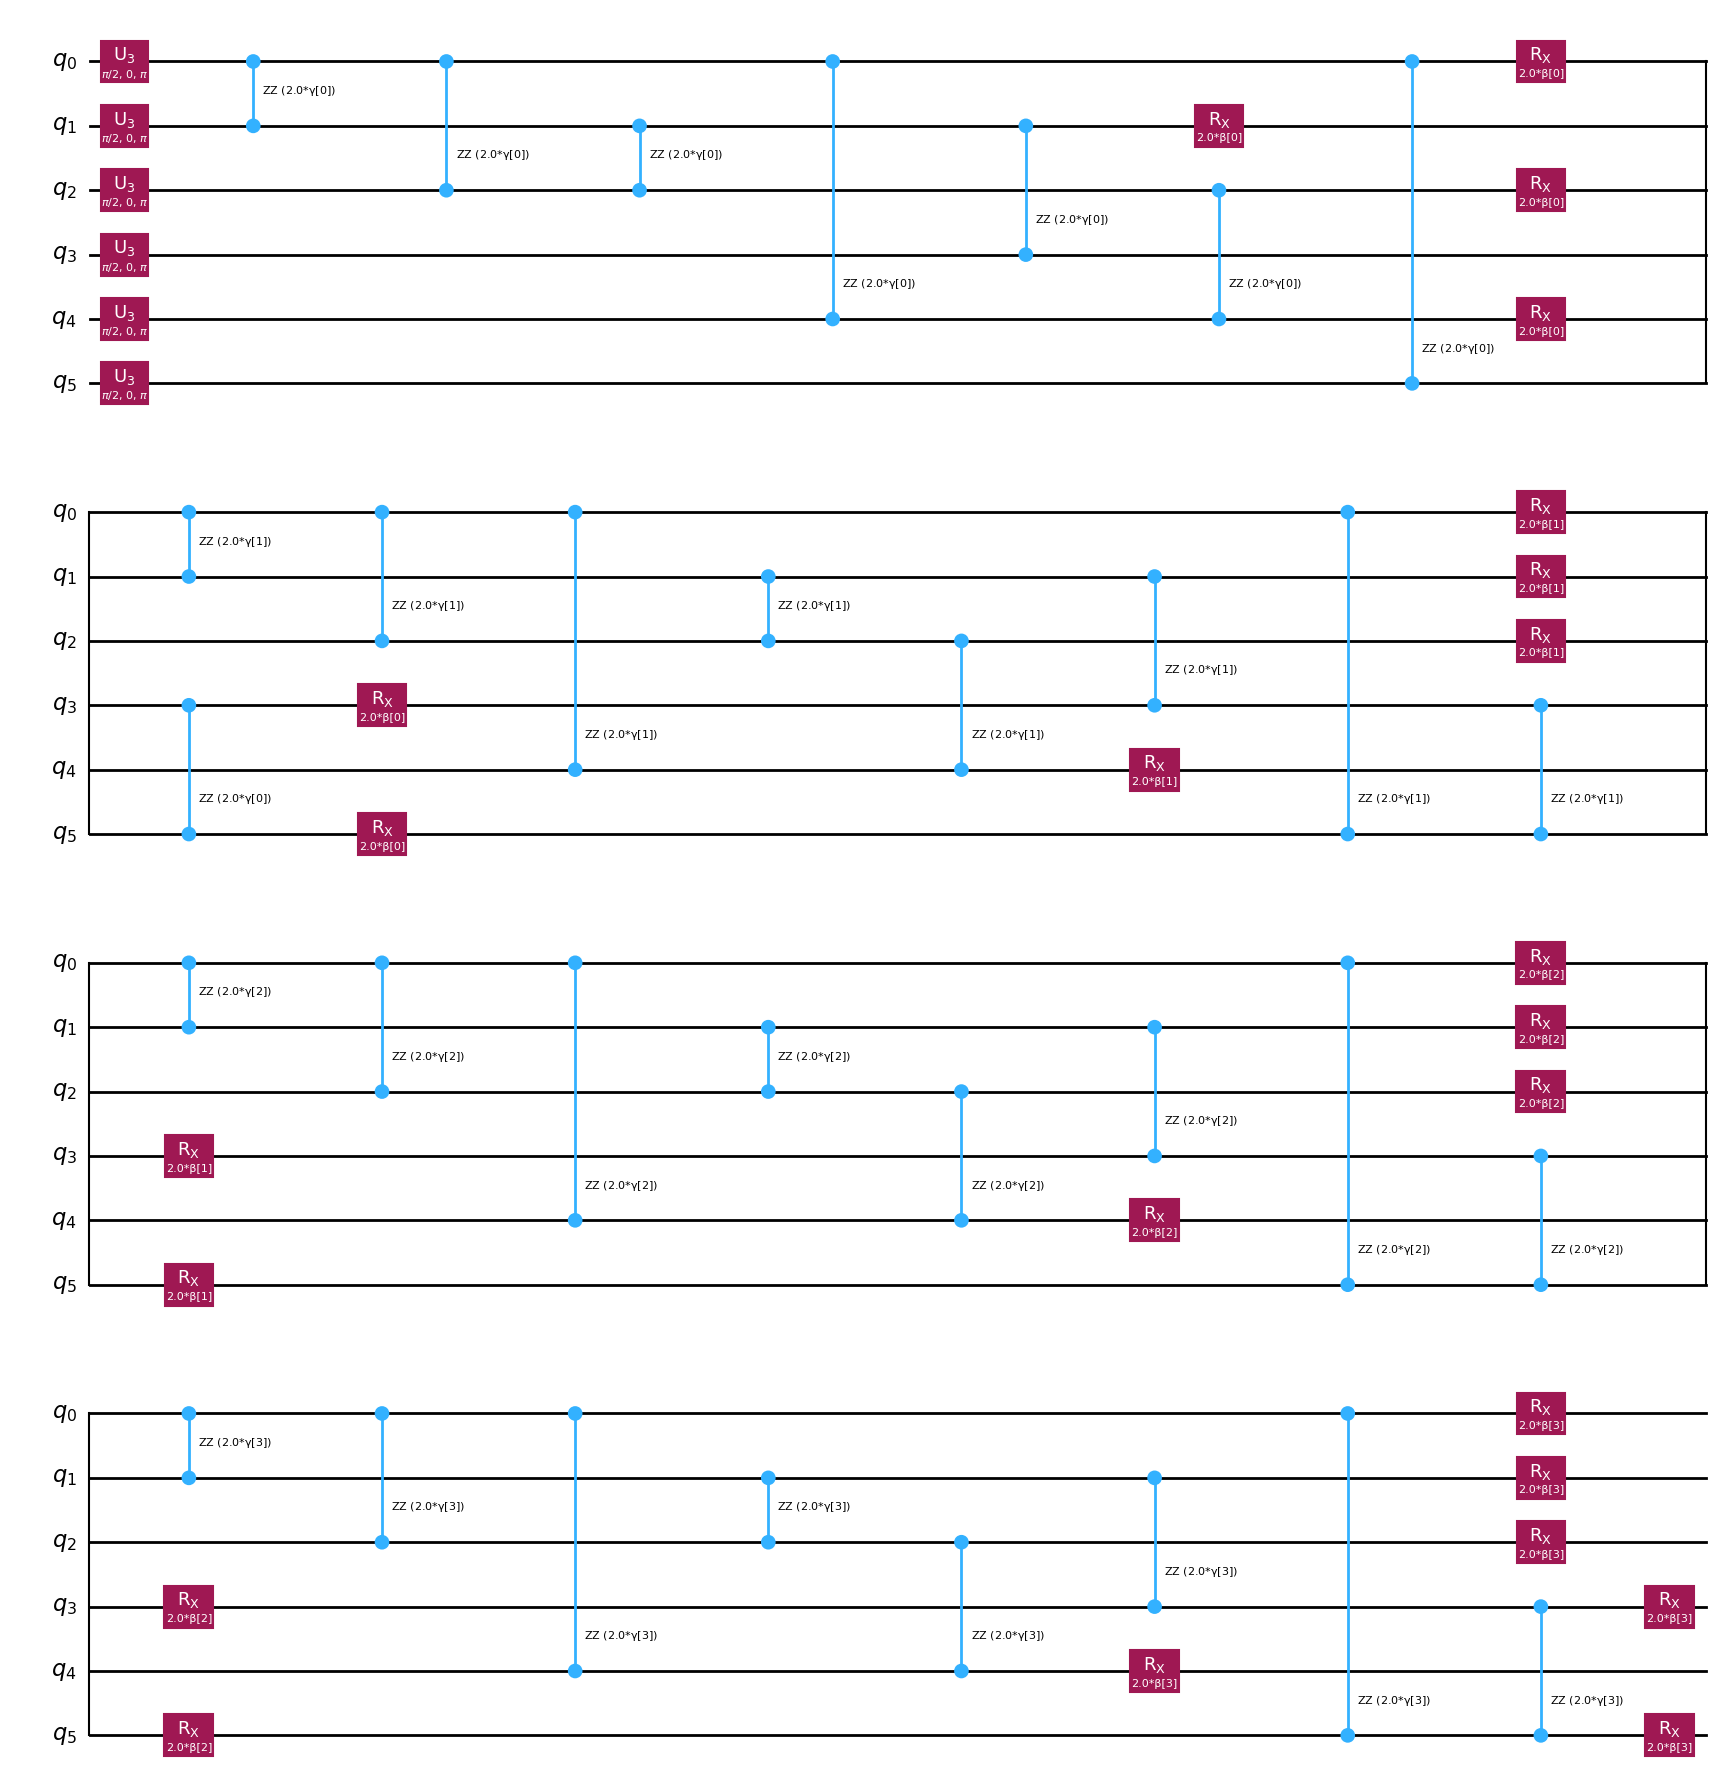

In [55]:
# Pre-defined ansatz circuit, operator class and visualization tools
from qiskit.circuit.library import QAOAAnsatz
from qiskit.quantum_info import SparsePauliOp

# QAOA ansatz circuit
ansatz = QAOAAnsatz(cost_hamiltonian, reps=4)
# Draw
ansatz.decompose(reps=3).draw("mpl")



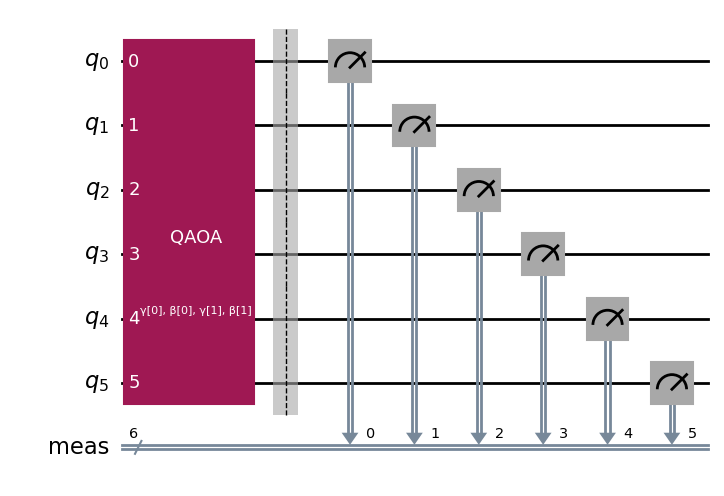

In [56]:
from qiskit.circuit.library import QAOAAnsatz

circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=2)
circuit.measure_all()

circuit.draw('mpl')

AerSimulator('aer_simulator')


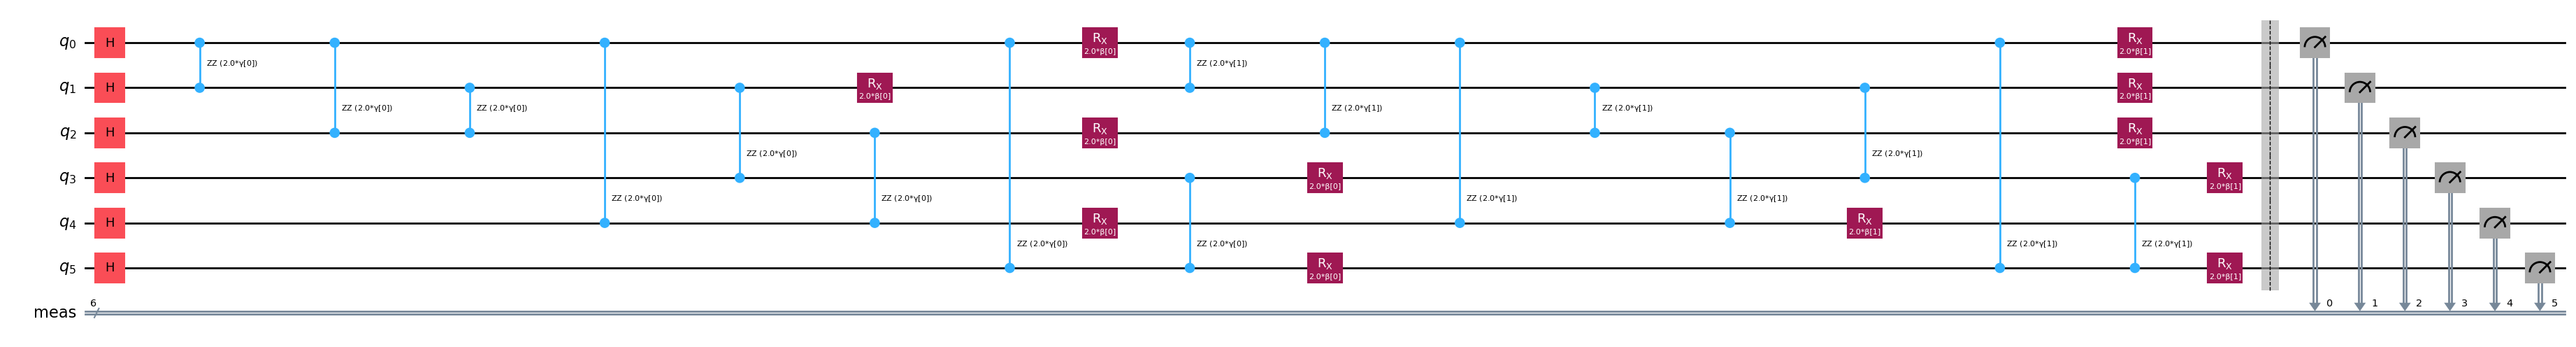

In [60]:
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager


# QiskitRuntimeService.save_account(channel="ibm_quantum", token="<MY_IBM_QUANTUM_TOKEN>", overwrite=True, set_as_default=True)

backend = AerSimulator()
print(backend)

# Create pass manager for transpilation
pm = generate_preset_pass_manager(optimization_level=3,
                                    backend=backend)

candidate_circuit = pm.run(circuit)
candidate_circuit.draw('mpl', fold=False, idle_wires=False)

In [61]:
initial_gamma = np.pi
initial_beta = np.pi/2
init_params = [initial_gamma, initial_beta, initial_gamma, initial_beta]

In [62]:
def cost_func_estimator(params, ansatz, hamiltonian, estimator):

    # transform the observable defined on virtual qubits to
    # an observable defined on all physical qubits
    isa_hamiltonian = hamiltonian.apply_layout(ansatz.layout)

    pub = (ansatz, isa_hamiltonian, params)
    job = estimator.run([pub])

    results = job.result()[0]
    cost = results.data.evs

    objective_func_vals.append(cost)


    return cost

In [63]:
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2 as Estimator
# SciPy minimizer routine
from scipy.optimize import minimize

objective_func_vals = [] # Global variable

# If using qiskit-ibm-runtime<0.24.0, change `mode=` to `session=`
estimator = Estimator()
estimator.options.default_shots = 1000

# Set simple error suppression/mitigation options

result = minimize(
    cost_func_estimator,
    init_params,
    args=(candidate_circuit, cost_hamiltonian, estimator),
    method="COBYLA",
    tol=1e-2,
)
print(result)

 message: Optimization terminated successfully.
 success: True
  status: 1
     fun: -3.373046875
       x: [ 4.090e+00  2.531e+00  2.765e+00  9.621e-02]
    nfev: 32
   maxcv: 0.0


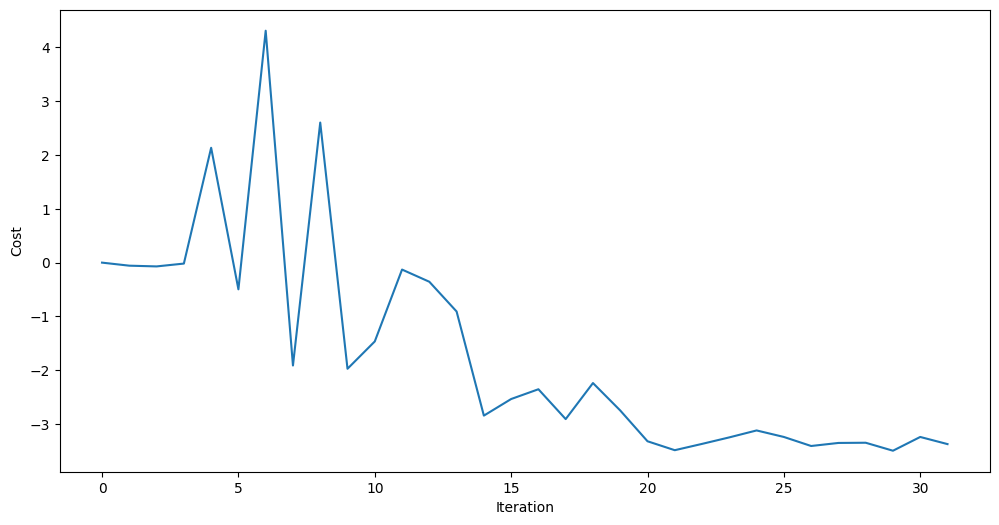

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(objective_func_vals)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

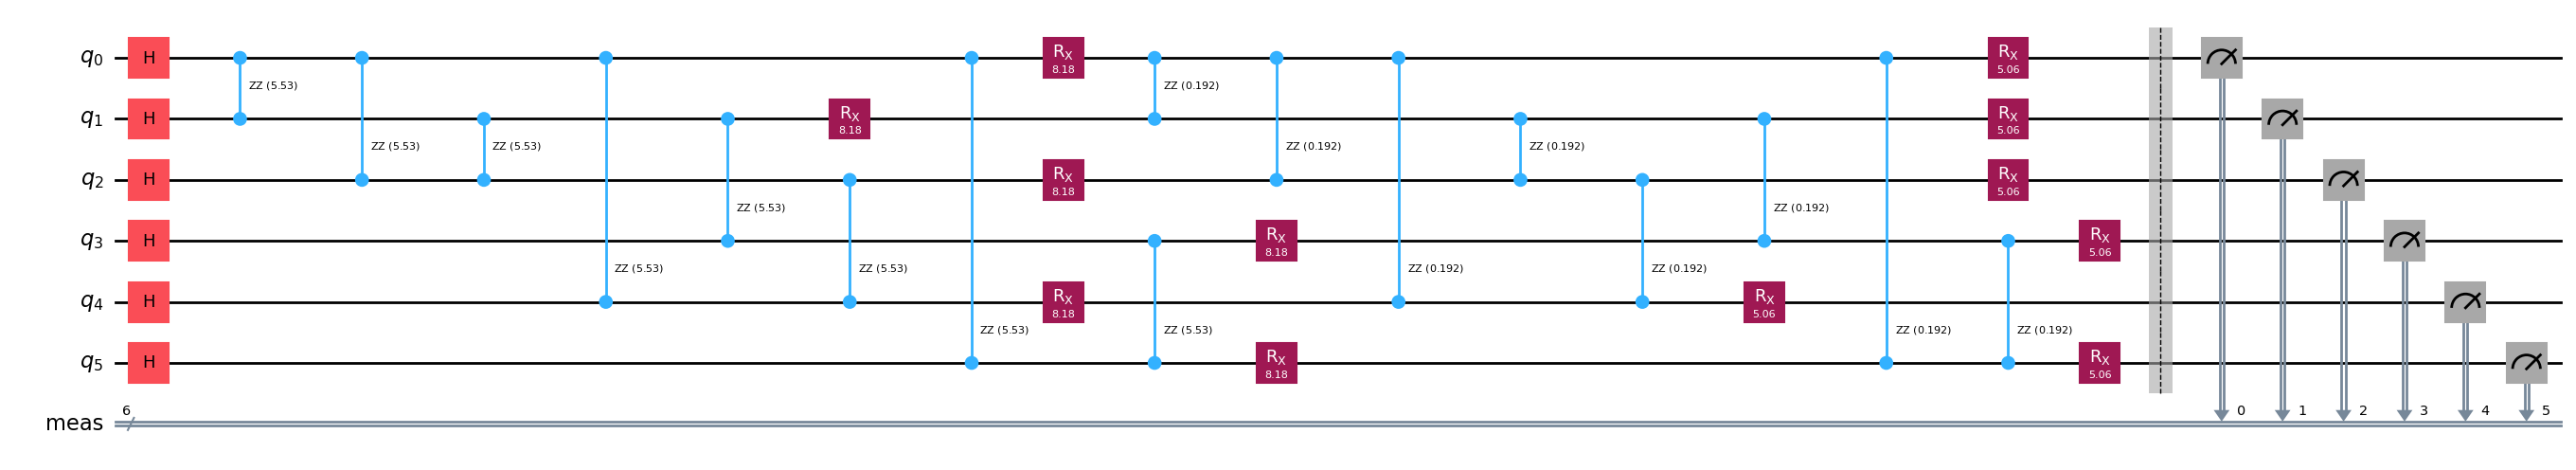

In [65]:
optimized_circuit = candidate_circuit.assign_parameters(result.x)
optimized_circuit.draw('mpl', fold=False, idle_wires=False)

In [66]:
from qiskit_aer.primitives import SamplerV2 as Sampler

# If using qiskit-ibm-runtime<0.24.0, change `mode=` to `backend=`
sampler = Sampler()
sampler.options.default_shots = 10000


pub= (optimized_circuit, )
job = sampler.run([pub], shots=int(1e4))
counts_int = job.result()[0].data.meas.get_int_counts()
counts_bin = job.result()[0].data.meas.get_counts()
shots = sum(counts_int.values())
final_distribution_int = {key: val/shots for key, val in counts_int.items()}
final_distribution_bin = {key: val/shots for key, val in counts_bin.items()}
print(final_distribution_int)

{60: 0.037, 36: 0.0143, 13: 0.154, 8: 0.0073, 25: 0.083, 28: 0.0327, 34: 0.0008, 62: 0.0002, 11: 0.0205, 47: 0.0016, 6: 0.0028, 49: 0.0089, 58: 0.0104, 15: 0.0031, 38: 0.0803, 46: 0.002, 5: 0.0097, 50: 0.1571, 59: 0.0015, 14: 0.0091, 37: 0.0372, 1: 0.0003, 54: 0.0301, 45: 0.006, 51: 0.0031, 4: 0.0014, 26: 0.0331, 18: 0.0059, 52: 0.019, 44: 0.0247, 3: 0.0361, 27: 0.0142, 43: 0.0007, 53: 0.0022, 2: 0.0012, 9: 0.0288, 19: 0.0228, 12: 0.0029, 61: 0.0017, 35: 0.0339, 33: 0.0034, 63: 0.0009, 10: 0.0022, 40: 0.0055, 30: 0.003, 7: 0.0028, 48: 0.0031, 0: 0.0016, 55: 0.0074, 22: 0.0029, 41: 0.0023, 23: 0.0065, 24: 0.0007, 20: 0.0009, 56: 0.0036, 57: 0.0028, 16: 0.0007, 31: 0.0031, 17: 0.0016, 32: 0.0027, 29: 0.0004, 39: 0.0003}


In [67]:
def to_bitstring(integer, num_bits):
    result = np.binary_repr(integer, width=num_bits)
    return [int(digit) for digit in result]

keys = list(final_distribution_int.keys())
values = list(final_distribution_int.values())
most_likely = keys[np.argmax(np.abs(values))]
most_likely_bitstring = to_bitstring(most_likely, len(graph))
most_likely_bitstring.reverse()

print("Result bitstring:", most_likely_bitstring)

Result bitstring: [0, 1, 0, 0, 1, 1]


C:\Users\opoog\AppData\Local\Temp\ipykernel_2944\3610143742.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.get_children()[int(p)].set_color("tab:purple")


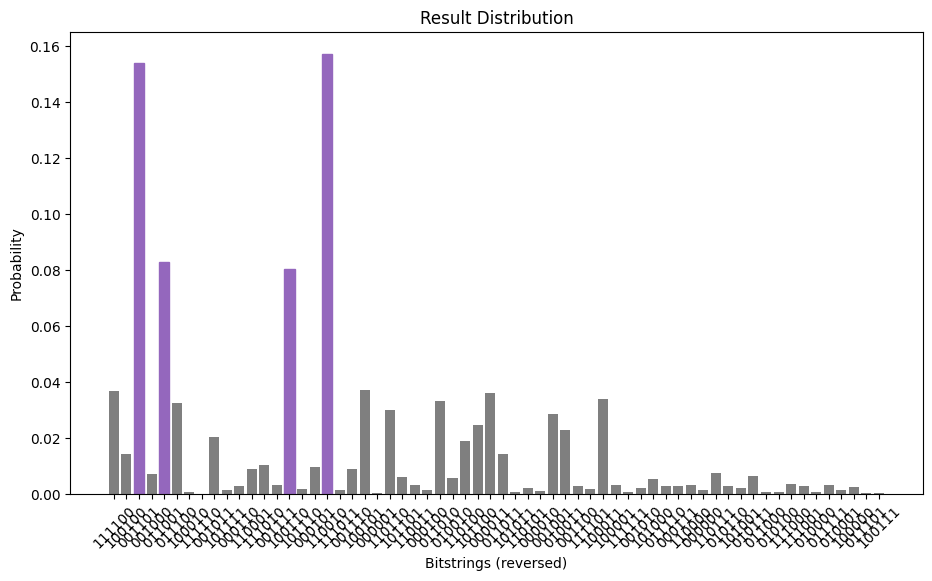

In [68]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams.update({"font.size": 10})
final_bits = final_distribution_bin
values = np.abs(list(final_bits.values()))
top_4_values = sorted(values, reverse=True)[:4]
positions = []
for value in top_4_values:
    positions.append(np.where(values == value)[0])
fig = plt.figure(figsize=(11, 6))
ax = fig.add_subplot(1, 1, 1)

plt.xticks(rotation=45)
plt.title("Result Distribution")
plt.xlabel("Bitstrings (reversed)")
plt.ylabel("Probability")
ax.bar(list(final_bits.keys()), list(final_bits.values()), color="tab:grey")
for p in positions:
    ax.get_children()[int(p)].set_color("tab:purple")
plt.show()

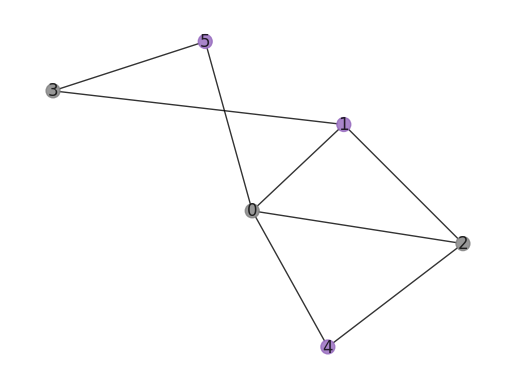

In [69]:
# auxiliary function to plot graphs
def plot_result(G, x):
    colors = ["tab:grey" if i == 0 else "tab:purple" for i in x]
    pos, default_axes = rx.spring_layout(G), plt.axes(frameon=True)
    rx.visualization.mpl_draw(G, node_color=colors, node_size=100, alpha=0.8, with_labels=True)


plot_result(graph, most_likely_bitstring)

In [70]:
from typing import Sequence
def evaluate_sample(x: Sequence[int], graph: rx.PyGraph) -> float:
    assert len(x) == len(list(graph.nodes())), "The length of x must coincide with the number of nodes in the graph."
    return sum(x[u] * (1 - x[v]) + x[v] * (1 - x[u]) for u, v in list(graph.edge_list()))


cut_value= evaluate_sample(most_likely_bitstring, graph)
print('The value of the cut is:', cut_value)

The value of the cut is: 7
